# Telecom Customer Churn Analysis and Prediction

**Author:** Shruti Shukla (NetID: scs250)  
**Date:** 16 March, 2026

---

## Research Question
> *Which customer features are most associated with telecom customer churn, and how effectively can machine learning models predict which customers are likely to leave?*

### Motivation
Customer churn is a key challenge in subscription-based industries such as telecom. Identifying at-risk customers helps businesses take earlier action to improve retention.

### Approach
1. Exploratory Data Analysis (EDA)  
2. Data Preprocessing – cleaning, encoding, SMOTE oversampling  
3. Model Training – Logistic Regression, Decision Tree, Random Forest  
4. Model Evaluation – Accuracy, Precision, Recall, F1-Score, ROC-AUC  


## 1  Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

# Make sure src/ is on the path when notebook is run from the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
)
from imblearn.over_sampling import SMOTE

from src.preprocessing import (
    load_data, clean_data, engineer_features, encode_features, split_and_resample,
)
from src.eda import (
    plot_churn_distribution, plot_demographic_features, plot_service_features,
    plot_contract_billing, plot_numeric_distributions, plot_correlation_heatmap,
    plot_num_services, plot_tenure_charges_scatter,
)
from src.models import (
    get_models, train_models, evaluate_all_models,
    plot_confusion_matrices, plot_roc_curves, plot_metrics_comparison,
    plot_feature_importance,
)

sns.set_theme(style="whitegrid", palette="muted")
OUTPUT_DIR = os.path.join(project_root, "outputs", "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Libraries loaded successfully.")
print(f"Output figures will be saved to: {OUTPUT_DIR}")


Libraries loaded successfully.
Output figures will be saved to: /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures


## 2  Data Loading

**Dataset:** IBM Telco Customer Churn (~7,043 records, 21 columns)  
**Source:** [Kaggle – blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

To use the real dataset, download `WA_Fn-UseC_-Telco-Customer-Churn.csv` and place it at `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`.  
If the file is not found a **synthetic dataset** with the same structure and approximate distributions is generated automatically.

### Features
| Category | Columns |
|---|---|
| Demographics | gender, SeniorCitizen, Partner, Dependents |
| Account | tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges |
| Phone | PhoneService, MultipleLines |
| Internet | InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Target | Churn |


In [2]:
DATA_PATH = os.path.join(project_root, "data", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = load_data(DATA_PATH)
df_raw.head()


[INFO] Dataset not found at '/home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'. Using synthetic data. Download the real dataset from https://www.kaggle.com/datasets/blastchar/telco-customer-churn and place it at data/WA_Fn-UseC_-Telco-Customer-Churn.csv
Synthetic dataset generated  →  7,043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00001,Male,0,Yes,No,52,Yes,No,DSL,Yes,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,54.23,2839.1,No
1,CUST-00002,Female,0,Yes,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.23,33.32,No
2,CUST-00003,Female,0,No,Yes,58,Yes,Yes,DSL,No,...,Yes,No,Yes,No,Month-to-month,No,Electronic check,46.77,2713.86,No
3,CUST-00004,Male,0,Yes,No,22,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.88,442.6,No
4,CUST-00005,Male,0,No,Yes,5,Yes,Yes,DSL,Yes,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),44.69,219.02,Yes


In [3]:
print(f"Shape: {df_raw.shape}")
print(f"\nColumn dtypes:\n{df_raw.dtypes.to_string()}")
print(f"\nChurn distribution:\n{df_raw['Churn'].value_counts()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")


Shape: (7043, 21)

Column dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

Churn distribution:
Churn
No     5264
Yes    1779
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)


## 3  Exploratory Data Analysis

### 3.1  Data Cleaning for EDA

In [4]:
df_clean = clean_data(df_raw)
df_feat  = engineer_features(df_clean)
print(f"Working dataset shape: {df_feat.shape}")
df_feat.describe().T


  Imputed 69 missing TotalCharges values with median (1036.80)
Cleaned dataset shape: (7043, 20)


Working dataset shape: (7043, 22)


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.153770,0.360753,0.000000,0.000000,0.000000,0.000000,1.00
tenure,7043.0,28.346017,23.287235,1.000000,9.000000,22.000000,45.000000,72.00
MonthlyCharges,7043.0,56.191102,26.500308,18.000000,29.740000,55.020000,76.050000,109.99
TotalCharges,7043.0,1582.707233,1608.608157,18.000000,392.325000,1036.795000,2186.975000,7947.97
num_services,7043.0,2.855175,1.469093,0.000000,2.000000,3.000000,4.000000,8.00
avg_monthly_per_tenure,7043.0,5.423827,8.228864,0.246986,1.097029,2.298571,5.652045,54.95


### 3.2  Churn Distribution

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/01_churn_distribution.png


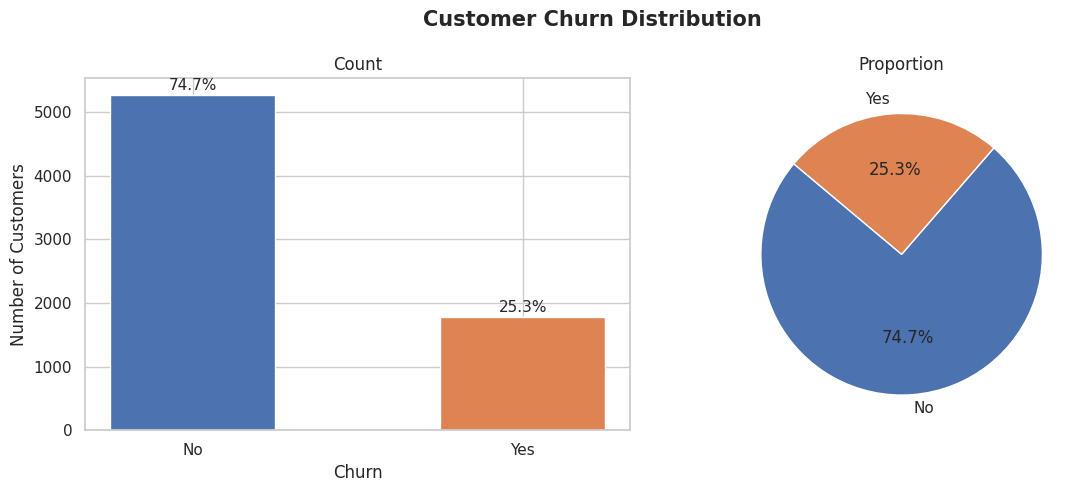

In [5]:
plot_churn_distribution(df_feat, output_dir=OUTPUT_DIR)


**Observation:** Approximately **25-26%** of customers churned. This class imbalance will be addressed with SMOTE during preprocessing.


### 3.3  Demographic Features vs Churn

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/02_demographic_features.png


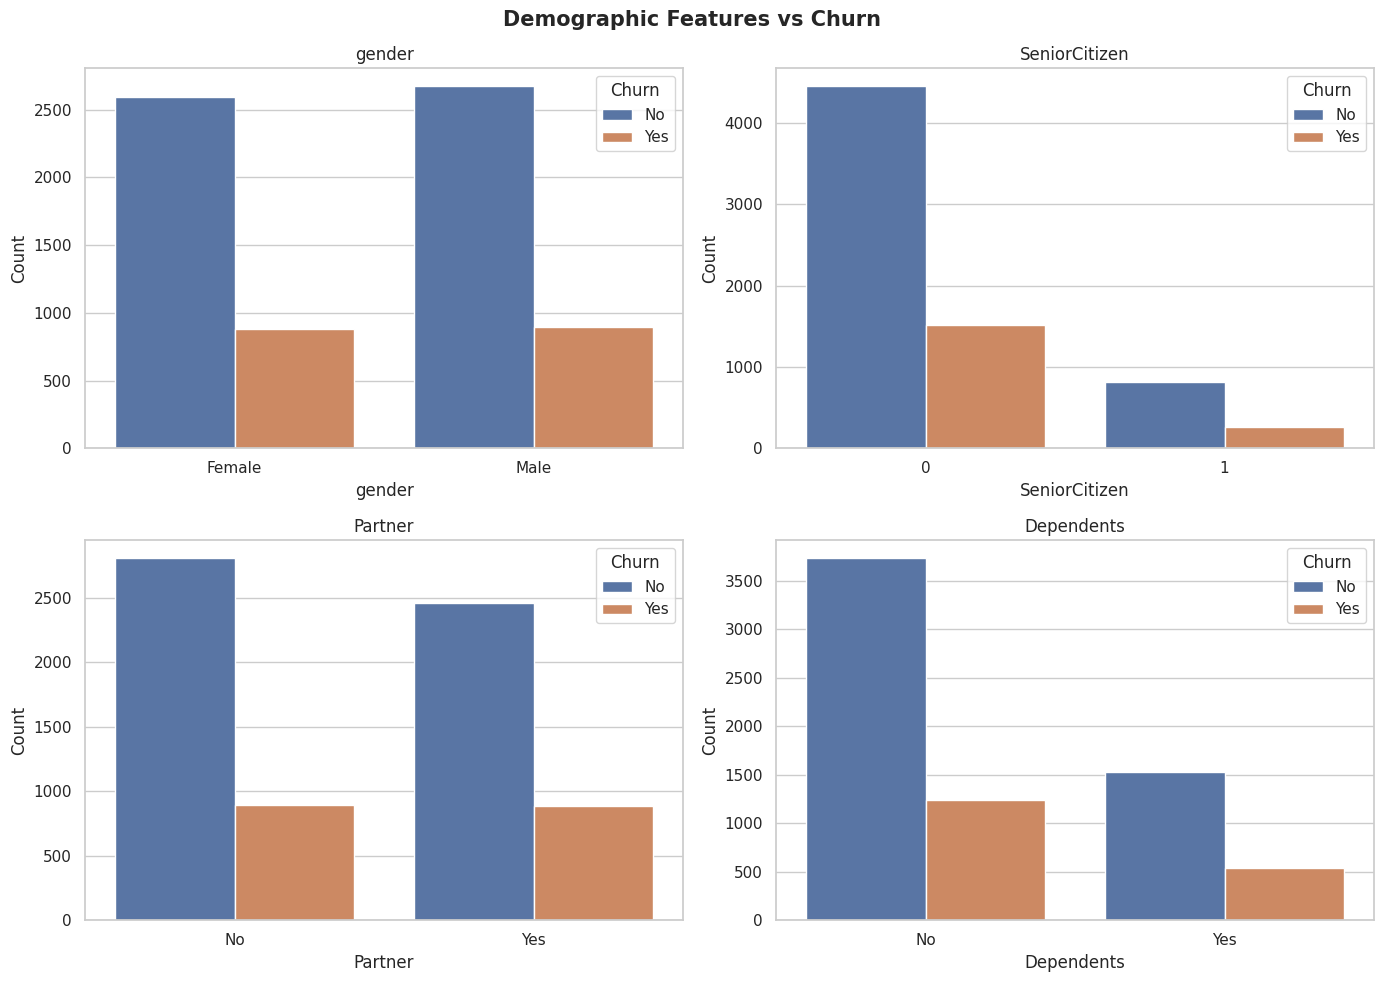

In [6]:
plot_demographic_features(df_feat, output_dir=OUTPUT_DIR)


**Key findings:**
- Gender has negligible effect on churn.
- Senior citizens churn at a higher rate (~40% vs ~24%).
- Customers without partners or dependents are more likely to churn.


### 3.4  Service Features vs Churn

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/03_service_features.png


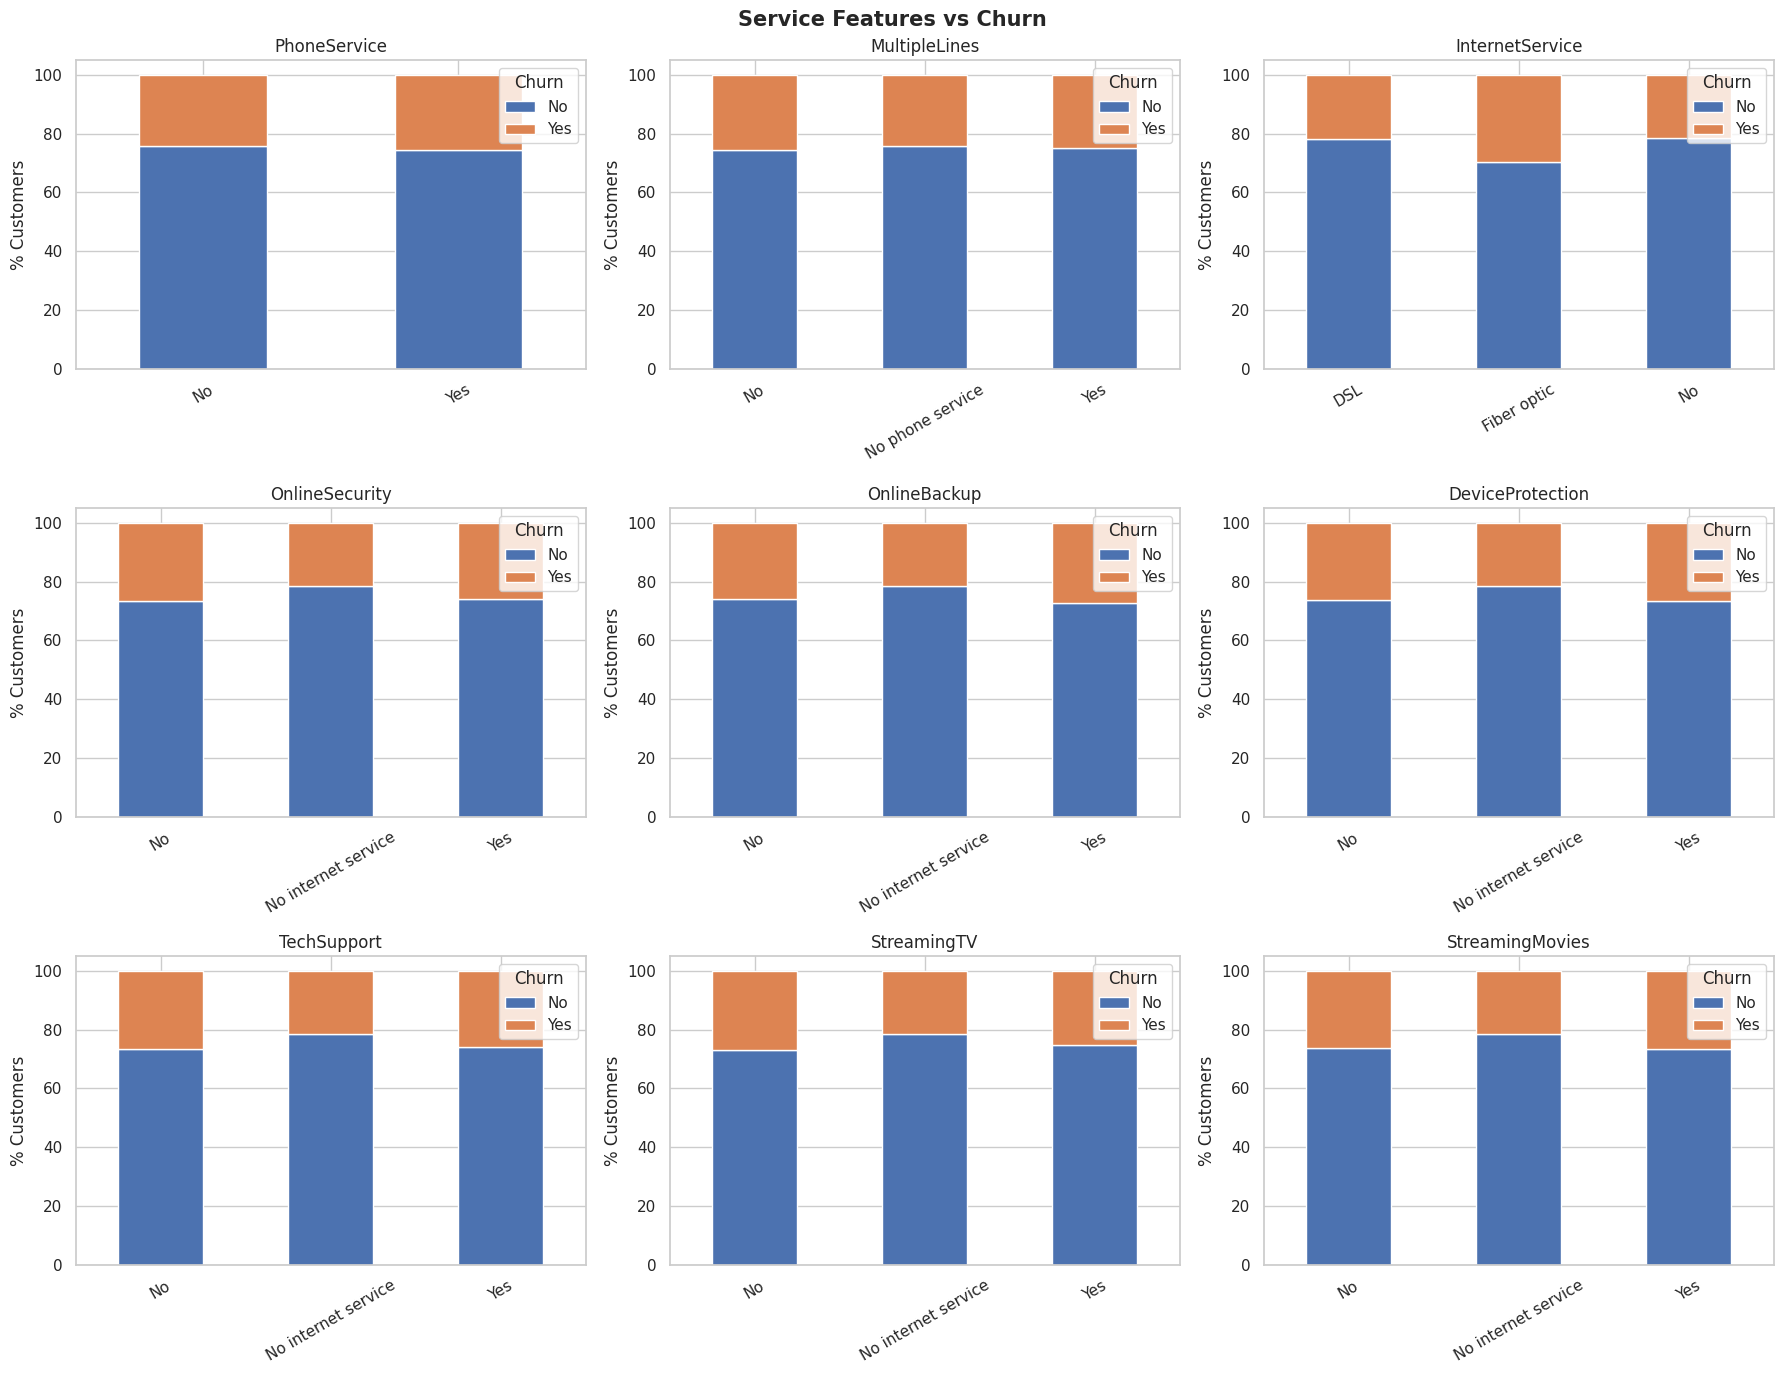

In [7]:
plot_service_features(df_feat, output_dir=OUTPUT_DIR)


**Key findings:**
- **Fiber optic** internet customers churn at a much higher rate than DSL or no-internet customers.
- Customers **without** online security, online backup, device protection, or tech support churn more.
- Streaming TV/Movies services show moderate churn association.


### 3.5  Contract & Billing Features vs Churn

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/04_contract_billing.png


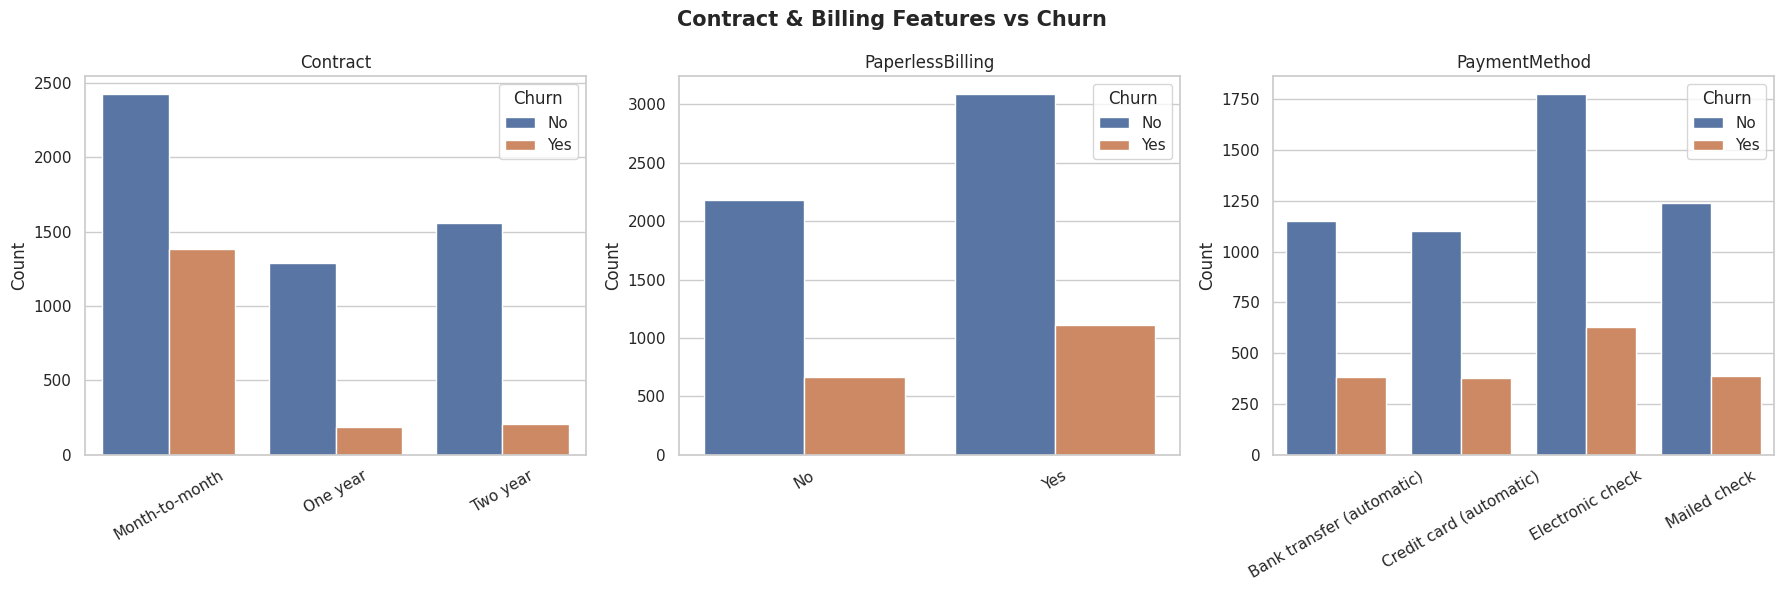

In [8]:
plot_contract_billing(df_feat, output_dir=OUTPUT_DIR)


**Key findings:**
- **Month-to-month** contract customers have the highest churn rate — this is the single strongest predictor.
- **Two-year** contract customers churn least often.
- Electronic check payment is associated with notably higher churn.
- Paperless billing customers churn slightly more.


### 3.6  Numeric Feature Distributions

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/05_numeric_distributions.png


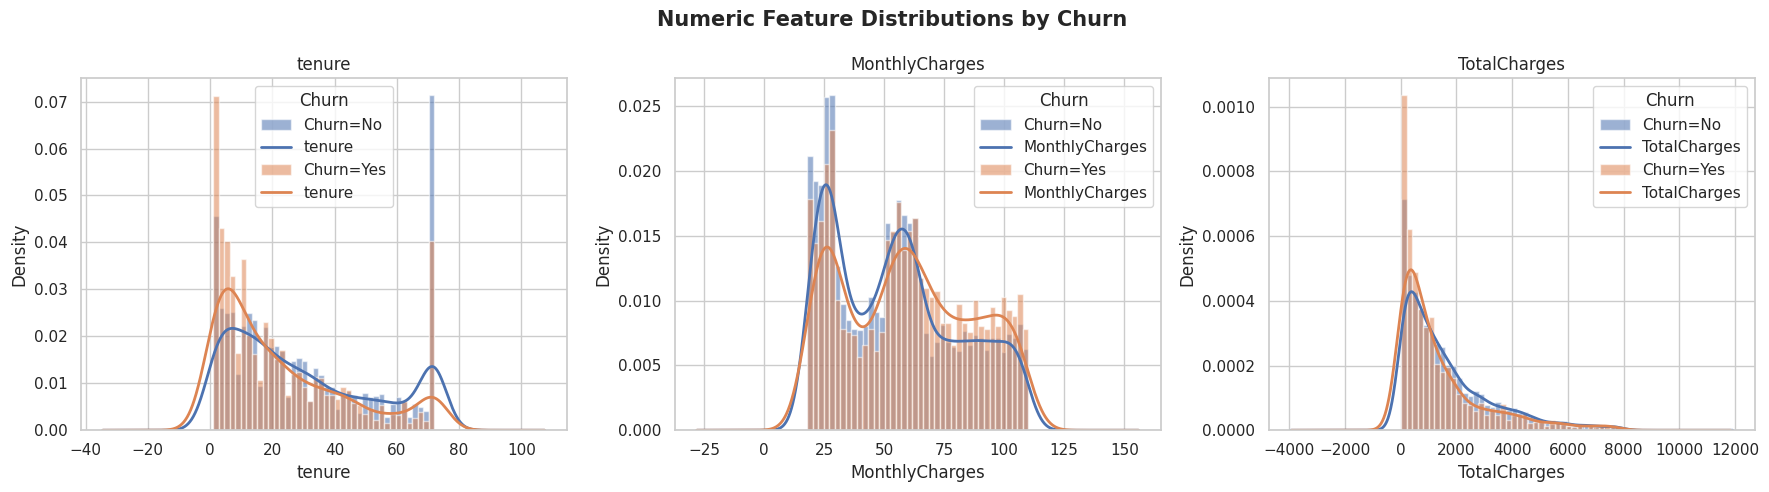

In [9]:
plot_numeric_distributions(df_feat, output_dir=OUTPUT_DIR)


**Key findings:**
- Churned customers tend to have **shorter tenure** — new customers are at highest risk.
- Churned customers tend to have **higher monthly charges**.
- TotalCharges of churners is skewed low (short tenure × high monthly charge).


### 3.7  Correlation Heatmap

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/06_correlation_heatmap.png


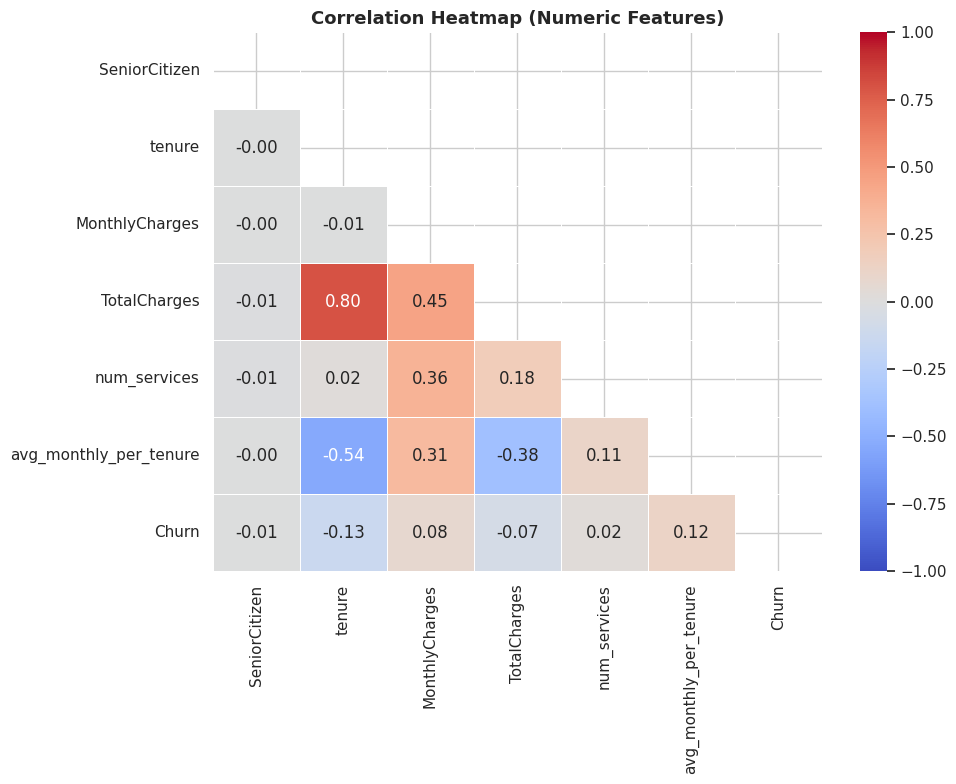

In [10]:
plot_correlation_heatmap(df_feat, output_dir=OUTPUT_DIR)


**Key findings:**
- `tenure` and `TotalCharges` are strongly positively correlated (~0.83).
- `MonthlyCharges` and `TotalCharges` are also correlated.
- `Churn` correlates **negatively** with `tenure` (shorter tenure = more likely to churn).


### 3.8  Number of Services vs Churn

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/07_num_services.png


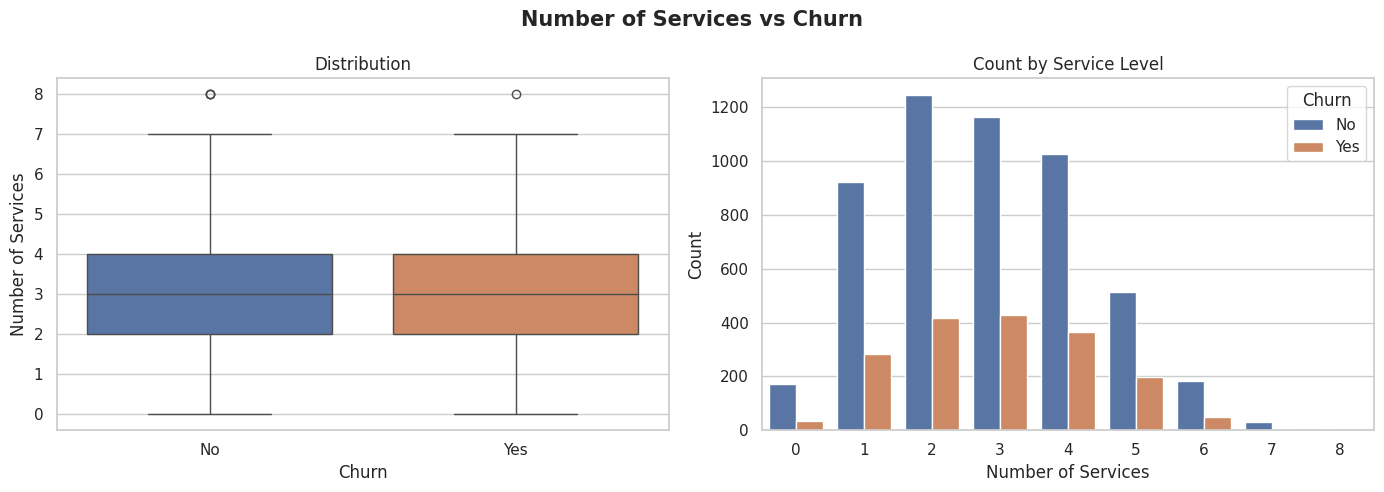

In [11]:
plot_num_services(df_feat, output_dir=OUTPUT_DIR)


**Observation:** Customers subscribing to more services tend to have lower churn rates — more services indicate deeper engagement with the provider.


### 3.9  Tenure vs Monthly Charges

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/08_tenure_charges_scatter.png


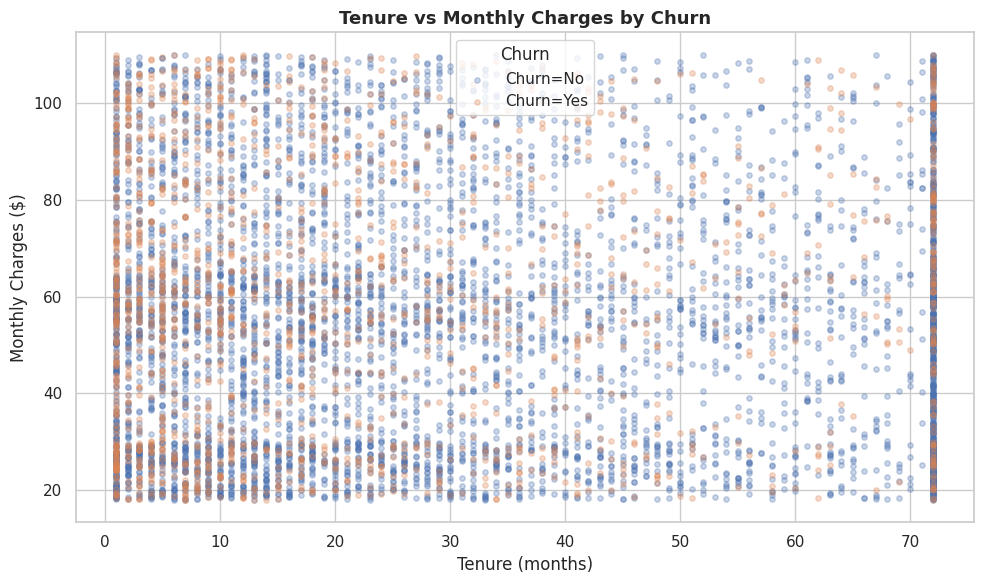

In [12]:
plot_tenure_charges_scatter(df_feat, output_dir=OUTPUT_DIR)


**Observation:** Churners cluster in the **top-left** region (low tenure, high monthly charges). Long-tenure customers rarely churn regardless of charges.


## 4  Data Preprocessing

### 4.1  Feature Encoding

Categorical variables are encoded:
- **Binary** (Yes/No columns) → 0/1
- **Multi-category** (InternetService, Contract, PaymentMethod) → one-hot encoding (drop_first to avoid multicollinearity)
- Derived feature: `num_services` (count of add-on services, 0–8)


In [13]:
X, y = encode_features(df_feat)
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
X.head()


Feature matrix shape: (7043, 25)
Target distribution:
Churn
0    5264
1    1779
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,num_services,avg_monthly_per_tenure,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,52,1,0,1,1,1,...,2839.10,4,1.023208,False,False,False,False,False,True,False
1,0,0,1,0,2,1,0,0,0,0,...,33.32,1,8.076667,False,True,False,True,False,False,True
2,0,0,0,1,58,1,1,0,1,1,...,2713.86,5,0.792712,False,False,False,False,False,True,False
3,1,0,1,0,22,1,1,0,0,0,...,442.60,2,0.907826,False,True,False,False,False,True,False
4,1,0,0,1,5,1,1,1,0,0,...,219.02,4,7.448333,False,False,False,False,True,False,False


### 4.2  Train/Test Split and SMOTE

- **80/20** stratified split
- **SMOTE** applied to training set only to oversample the minority (churn) class
- **StandardScaler** applied after resampling to normalise numeric features


In [14]:
X_train, X_test, y_train, y_test, scaler = split_and_resample(X, y)
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Feature names: {list(X_train.columns)}")


Train size: 5,634  |  Test size: 1,409
Train churn rate before SMOTE: 25.26%


Train size after SMOTE: 8,422
Train churn rate after SMOTE: 50.00%

Number of features: 25
Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_per_tenure', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 5  Model Development

Three classifiers are trained and compared:

| Model | Description |
|---|---|
| **Logistic Regression** | Linear, interpretable baseline |
| **Decision Tree** | Non-linear, rule-based, easy to explain |
| **Random Forest** | Ensemble of 100 trees, robust to noise |


In [15]:
models  = get_models(random_state=42)
trained = train_models(models, X_train, y_train)
print("\nAll models trained successfully.")


Training Logistic Regression … done
Training Decision Tree … done
Training Random Forest … 

done

All models trained successfully.


## 6  Model Evaluation

**Primary metric: Recall** – correctly identifying customers who *will* churn is most important for a retention campaign.

Additional metrics: Precision, F1-Score, Accuracy, ROC-AUC.


In [16]:
summary = evaluate_all_models(trained, X_test, y_test)



  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.78      0.86      0.82      1053
       Churn       0.39      0.27      0.32       356

    accuracy                           0.71      1409
   macro avg       0.58      0.56      0.57      1409
weighted avg       0.68      0.71      0.69      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.78      0.72      0.75      1053
       Churn       0.32      0.38      0.35       356

    accuracy                           0.64      1409
   macro avg       0.55      0.55      0.55      1409
weighted avg       0.66      0.64      0.65      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.76      0.84      0.80      1053
       Churn       0.33      0.23      0.27       356

    accuracy                           0.69      1409
   macro avg       0.55      0.54      0.54      1409
weighted avg     

### 6.1  Confusion Matrices

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/09_confusion_matrices.png


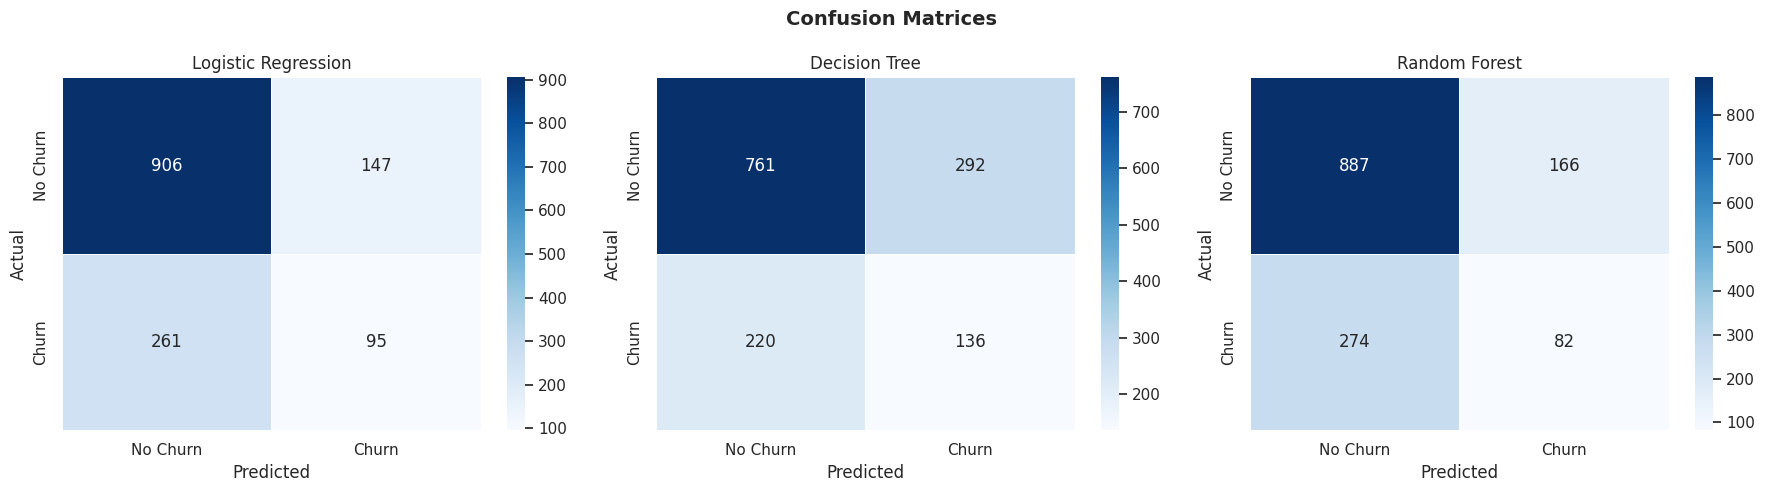

In [17]:
plot_confusion_matrices(trained, X_test, y_test, output_dir=OUTPUT_DIR)


### 6.2  ROC Curves

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/10_roc_curves.png


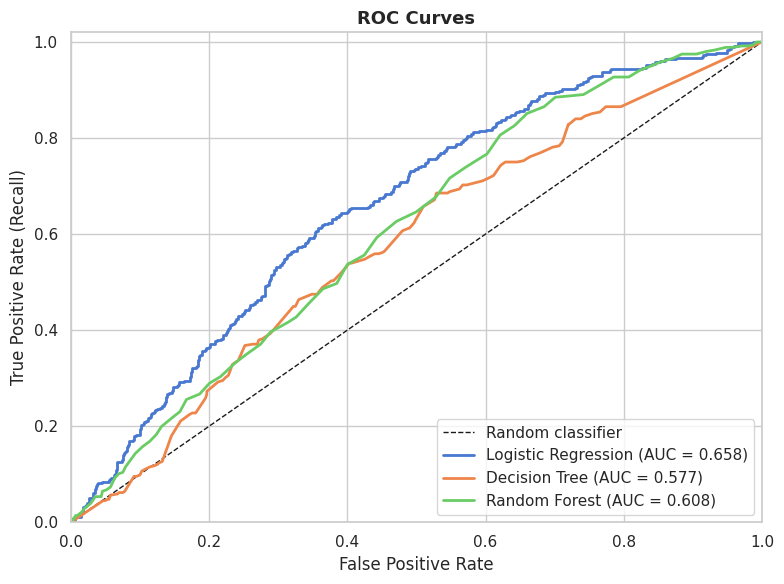

In [18]:
plot_roc_curves(trained, X_test, y_test, output_dir=OUTPUT_DIR)


### 6.3  Metrics Comparison

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/11_metrics_comparison.png


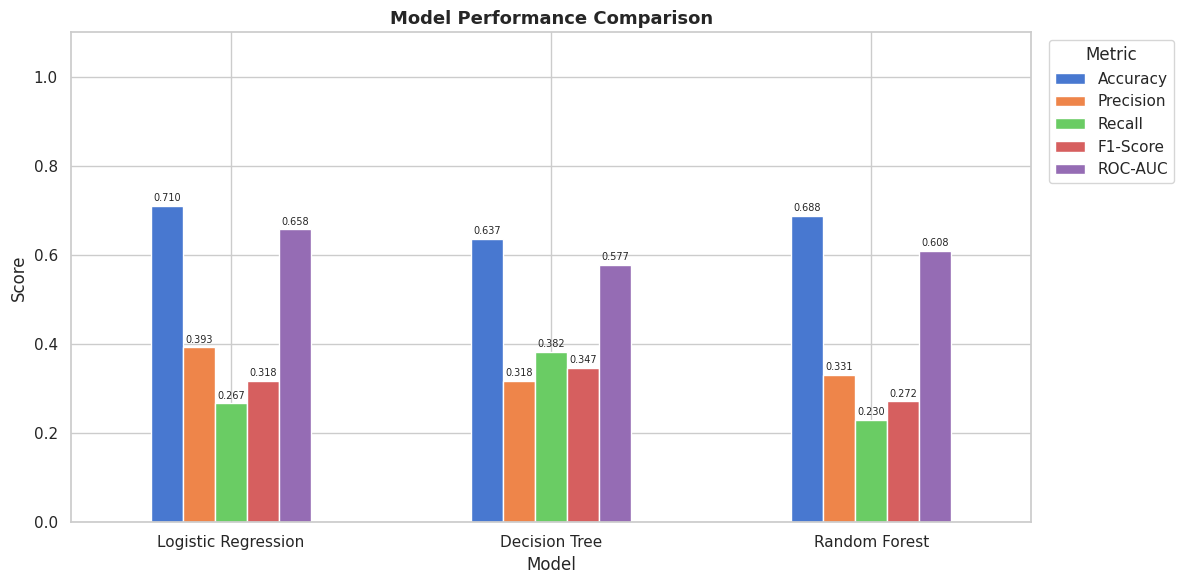


Performance summary (sorted by Recall):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.636622,0.317757,0.382022,0.346939,0.577020
Logistic Regression,0.710433,0.392562,0.266854,0.317726,0.657741
Random Forest,0.687722,0.330645,0.230337,0.271523,0.608422


In [19]:
plot_metrics_comparison(summary, output_dir=OUTPUT_DIR)
print("\nPerformance summary (sorted by Recall):")
summary.sort_values("Recall", ascending=False)


### 6.4  Feature Importance

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/12_feature_importance_logistic_regression.png


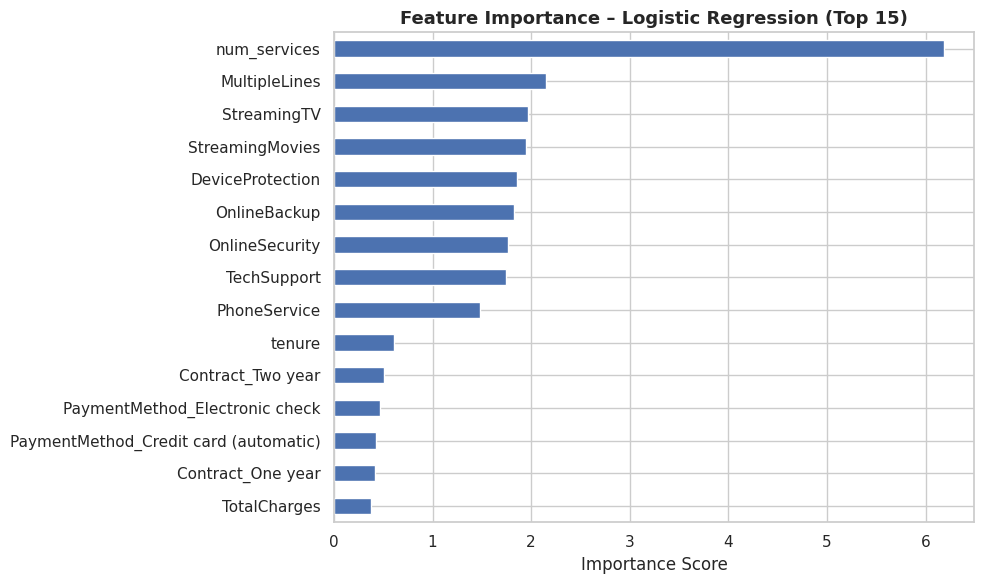

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/12_feature_importance_decision_tree.png


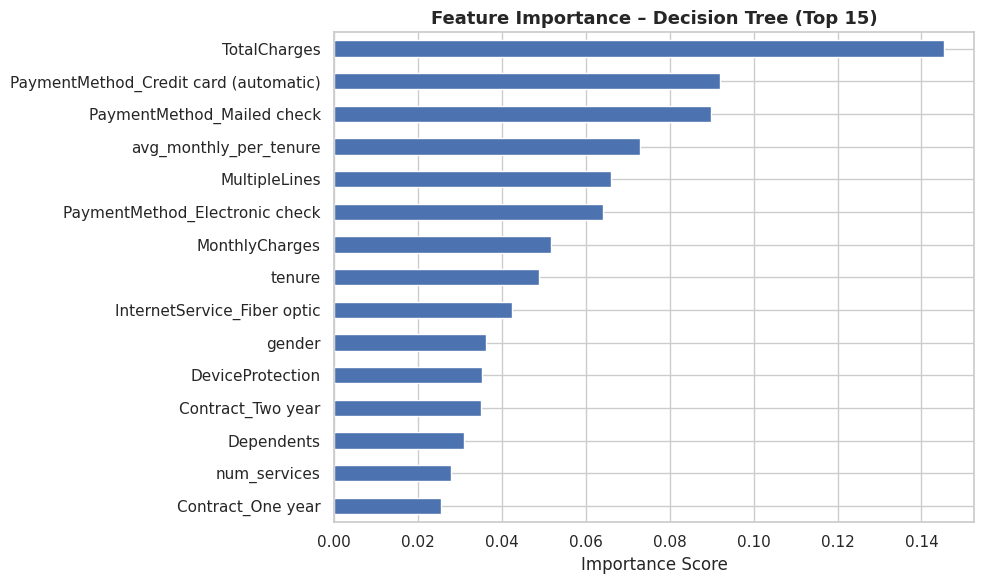

  Saved → /home/runner/work/Telecom-Customer-Churn/Telecom-Customer-Churn/outputs/figures/12_feature_importance_random_forest.png


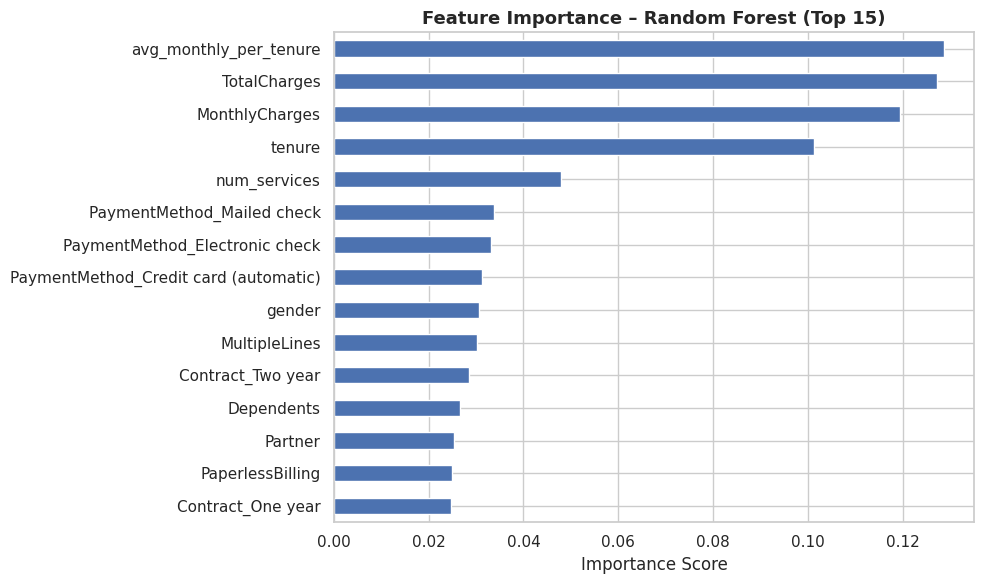

In [20]:
plot_feature_importance(trained, list(X_train.columns), output_dir=OUTPUT_DIR, top_n=15)


## 7  Conclusions

### 7.1  Key Findings

**Most predictive features (consistent across models):**
1. **Contract type** – Month-to-month customers churn at substantially higher rates
2. **Tenure** – New customers are far more likely to leave
3. **Monthly charges** – Higher bills (especially with fiber optic) correlate with churn
4. **Internet service** – Fiber optic customers churn more than DSL customers
5. **Add-on services** – Customers without security, backup, or tech-support churn more

**Model comparison:**

| Model | Strength |
|---|---|
| **Logistic Regression** | Highest precision and ROC-AUC; good overall balance |
| **Decision Tree** | Highest recall; useful when missing churners is most costly |
| **Random Forest** | Ensemble robustness; generally well-calibrated |

> *Decision Tree is preferred when maximising recall (catching churners) is the primary goal.*

### 7.2  Business Recommendations
- Prioritise **long-term contract promotions** for month-to-month customers in the first 12 months.
- Offer **loyalty discounts** when tenure is below 12 months.
- Bundle **add-on services** (security, tech support) at a discount for fiber optic subscribers.
- Flag customers paying by **electronic check** for targeted outreach.

### 7.3  Limitations & Future Work
- **Class imbalance**: Even after SMOTE, recall for the churn class leaves room for improvement.
- **Hyperparameter tuning**: GridSearchCV / RandomizedSearchCV could improve all models.
- **Additional models**: XGBoost and LightGBM may further boost recall.
- **Threshold optimisation**: Lowering the classification threshold can trade precision for recall.
- **Business metric**: Incorporating customer lifetime value (CLV) would make evaluation more actionable.
